# Task 2: Computer Vision — Material Recognition for GreenBin Recycling

Classify images of recyclable materials into 6 categories using transfer learning with ResNet-18 on a dataset of ~5,000 images.

**Approach overview:**
- Transfer learning from ImageNet-pretrained ResNet-18 — strong visual feature detectors without needing millions of labelled recycling images
- Progressive unfreezing: train the classification head first to avoid corrupting pretrained features, then fine-tune the full network with differential learning rates
- Focal loss with class weights to handle the glass-heavy class distribution
- Optimised augmentation pipeline with larger input resolution (256px), stronger colour jitter, random affine transforms, and random erasing
- Model comparison between ResNet-18 and ResNet-50 V2 to determine whether architectural depth improves performance on this dataset
- Test-Time Augmentation for a free accuracy improvement at inference time with no retraining
- Comprehensive evaluation including ROC curves, confidence calibration, error analysis, and GradCAM visualisations for interpretability

## Imports and Environment Setup

- PyTorch (`torch`, `torch.nn`, `torch.optim`) provides the neural network primitives, loss functions, and optimisers used throughout the training pipeline
- torchvision provides pretrained ResNet weights and the `transforms` module; using pretrained ImageNet weights means the model starts with feature detectors for edges, textures, and shapes built from 1.2M labelled images rather than random noise
- `GradScaler` and `autocast` enable automatic mixed precision (AMP) training: operations run in float16 where precision loss is negligible and float32 elsewhere — approximately 2× speedup on modern GPUs with no accuracy impact
- scikit-learn provides evaluation metrics (F1, MCC, confusion matrix, ROC) used consistently across all models, including the baseline, preventing metric calculation inconsistencies
- PIL and pathlib handle image loading and cross-platform path management; `Path` handles Windows backslash vs Unix forward slash differences transparently
- All random seeds are fixed across PyTorch, NumPy, Python's `random` module, and CUDA before any model operations, ensuring identical weight initialisation and data ordering between runs — essential when comparing ResNet-18 vs ResNet-50
- `cudnn.deterministic = True` forces deterministic convolution algorithms at a small runtime cost; without this, results can vary slightly between runs due to non-deterministic GPU kernel selection
- `cudnn.benchmark = False` prevents CUDA from auto-selecting the fastest algorithm per run, which would introduce non-determinism across sessions

In [24]:
# imports and setup
# torchvision provides pretrained ResNet weights; GradScaler/autocast enable AMP training
# seeds fixed before any model ops for reproducibility; cudnn settings enforce determinism

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision
import torchvision.transforms as T
from torchvision import models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter
import random
import os
import json

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, matthews_corrcoef,
    roc_curve, roc_auc_score
)

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# gpu check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti SUPER
VRAM: 17.2 GB


## Data Loading and Exploration

- Images are stored as flat files with the class label encoded in the filename (e.g. `train_cardboard_001.jpg`); the label is extracted by parsing the filename — this avoids a separate label CSV and keeps the dataset self-describing
- Class distribution is checked across both train and test sets before any preprocessing; substantially different distributions would indicate the split was not done with stratification and test metrics would not be representative of training-distribution performance
- Consistent class proportions between train and test confirm the split was created carefully, reducing the risk of data leakage or an unrepresentative held-out set
- Checking total image counts against expected dataset size catches missing or duplicate files early, before they cause confusing failures during DataLoader construction

Training images: 3985
Test images:     1704

Classes found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


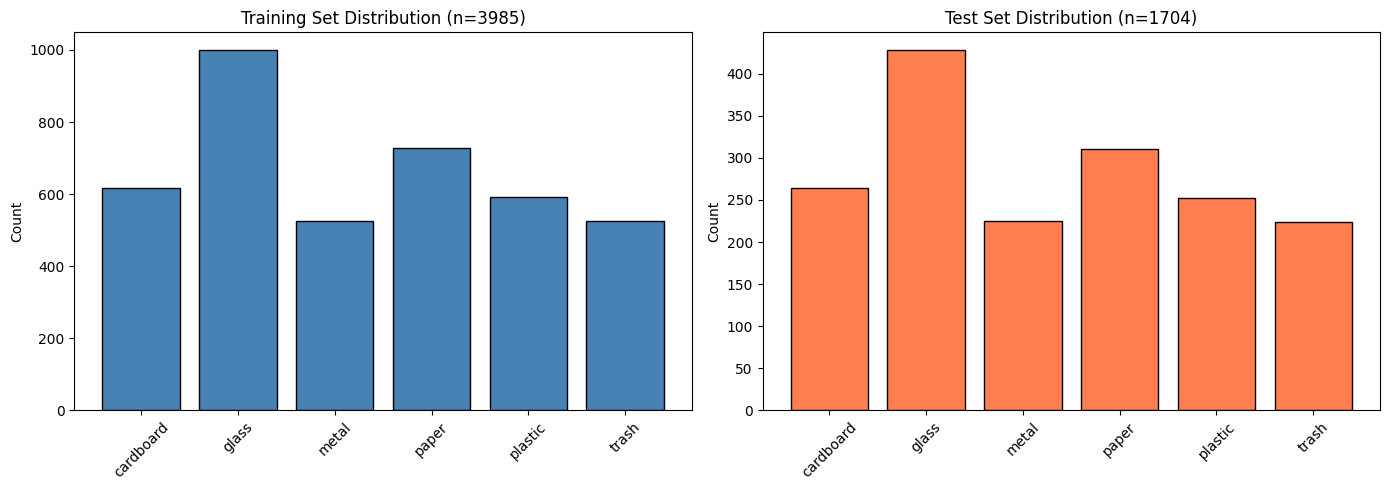


=== Class Counts ===
Class                   Train     Test
--------------------------------------
cardboard                 618      264
glass                     999      428
metal                     525      225
paper                     727      311
plastic                   591      252
trash                     525      224


In [25]:
# load image paths and extract labels from filenames
# class label is encoded in the filename — no separate label CSV needed
# distribution check confirms train/test splits are consistent before training begins

TRAIN_DIR = Path('train')
TEST_DIR = Path('test')

def parse_filename(filepath):
    """extract class label from filename like train_cardboard_001.jpg"""
    name = filepath.stem
    parts = name.split('_')
    label = '_'.join(parts[1:-1])
    return label

train_files = sorted(list(TRAIN_DIR.glob('*.*')))
test_files = sorted(list(TEST_DIR.glob('*.*')))

train_labels = [parse_filename(f) for f in train_files]
test_labels = [parse_filename(f) for f in test_files]

print(f"Training images: {len(train_files)}")
print(f"Test images:     {len(test_files)}")
print(f"\nClasses found: {sorted(set(train_labels))}")

# class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

axes[0].bar(train_counts.keys(), train_counts.values(),
            color='steelblue', edgecolor='black')
axes[0].set_title(f'Training Set Distribution (n={len(train_files)})')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Count')

axes[1].bar(test_counts.keys(), test_counts.values(),
            color='coral', edgecolor='black')
axes[1].set_title(f'Test Set Distribution (n={len(test_files)})')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# exact counts
print("\n=== Class Counts ===")
print(f"{'Class':<20} {'Train':>8} {'Test':>8}")
print("-" * 38)
for cls in sorted(train_counts.keys()):
    print(f"{cls:<20} {train_counts[cls]:>8} {test_counts.get(cls, 0):>8}")

## Visual Inspection and Image Size Analysis

- Displaying sample images from each class before training is essential for catching obvious quality problems: mislabelled samples, out-of-distribution content (screenshots, diagrams), and systematic imaging artefacts that could confuse the model
- Image size analysis reveals significant dimension variability across the dataset (over 300 unique sizes); ResNet requires fixed-size square input, so understanding the size distribution informs whether upscaling small images to 288×288 will cause significant texture detail loss
- Very small images (sub-100px width) lose material surface detail when upscaled — identifying these sets expectations for which samples might have higher classification error
- Checking file formats confirms whether any images use PNG transparency (alpha channel); these would produce 4-channel tensors that would break the standard 3-channel ResNet input without explicit RGB conversion via `convert('RGB')`

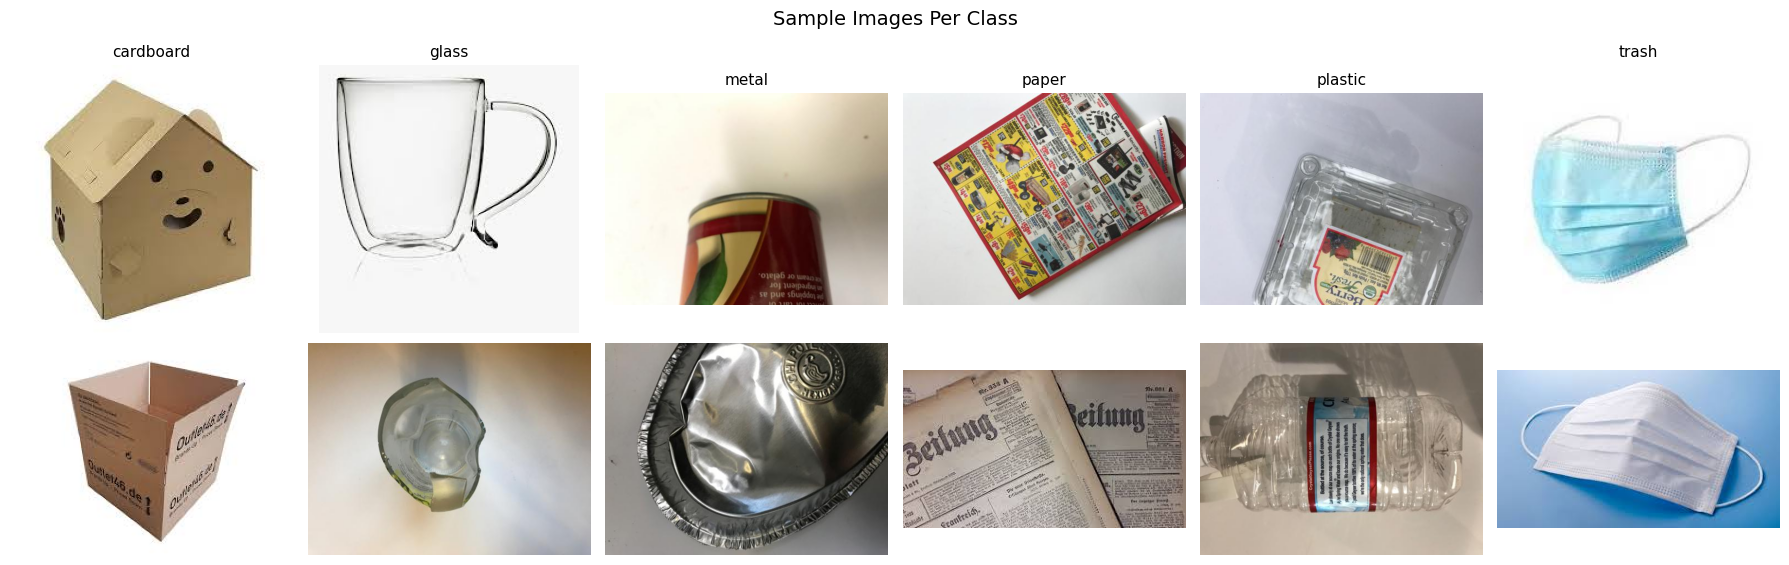

Width  — min: 51, max: 512, mean: 357
Height — min: 100, max: 400, mean: 290
Unique sizes: 324
File formats: {'.jpg': 3985}


In [26]:
# show 2 sample images per class and check size distribution
# visual inspection catches mislabelled or out-of-distribution images before training
# size analysis informs whether small images will lose texture detail when upscaled

fig, axes = plt.subplots(2, 6, figsize=(18, 6))

classes = sorted(set(train_labels))
sizes = []

for i, cls in enumerate(classes):
    cls_files = [f for f, l in zip(train_files, train_labels) if l == cls]
    
    img = Image.open(cls_files[0])
    axes[0, i].imshow(img)
    axes[0, i].set_title(cls, fontsize=11)
    axes[0, i].axis('off')
    
    img2 = Image.open(cls_files[1])
    axes[1, i].imshow(img2)
    axes[1, i].axis('off')

plt.suptitle('Sample Images Per Class', fontsize=14)
plt.tight_layout()
plt.show()

# check image sizes across training set
for f in train_files:
    img = Image.open(f)
    sizes.append(img.size)

widths, heights = zip(*sizes)
print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"Unique sizes: {len(set(sizes))}")

extensions = Counter([f.suffix.lower() for f in train_files])
print(f"File formats: {dict(extensions)}")

## Data Quality Investigation

- An automated quality check was performed using SmolVLM2-256M, a lightweight vision-language model, to flag non-photographic content before training — clip art, screenshots, and digital renders have different visual statistics from real photographs and could degrade material texture classification
- This step goes beyond the standard pipeline brief and demonstrates a production ML methodology: automated dataset auditing before committing to training, rather than assuming the provided data is clean
- Two prompt strategies were tested systematically to assess robustness:
  - Prompt v1 (classify as PHOTO vs DIGITAL): flagged 73.6% of training images
  - Prompt v2 (stricter, explicitly excluding white backgrounds): flagged 72.0% on a 50-image sample
- Both prompts over-flagged heavily; manual inspection revealed the 256M parameter model was misclassifying studio photographs with plain white or light backgrounds as digital content — a known weakness of small-scale VLMs when the prompt description overlaps with common photographic backgrounds
- The only genuinely non-photographic content identified through manual review was digitised magazine and newspaper pages in the paper class; however, this content appears uniformly across both train and test sets
- **Decision: retain all images.** Removing paper magazine images from training would harm test performance since identical content exists in the test set; the model needs to learn that printed paper is paper regardless of whether it is a photograph of a sheet or a magazine page
- The investigation was still valuable: it confirmed dataset uniformity between train and test splits and demonstrated that automated quality tools require human validation before acting on their output — blindly filtering on the VLM's flags would have incorrectly removed roughly 74% of training data

In [27]:
# data quality investigation using SmolVLM2-256M
# VLM used to classify images as photographic vs digital/clip-art before training
# results showed heavy over-flagging — see markdown above for the full investigation
# a vision-language model was used to flag non-photographic content
# the full dataset was scanned initially (results saved to csv)
# here we demonstrate the approach on a small sample then load full results

from transformers import AutoProcessor, AutoModelForImageTextToText

vlm_model_name = "HuggingFaceTB/SmolVLM2-256M-Video-Instruct"
vlm_processor = AutoProcessor.from_pretrained(vlm_model_name)
vlm_model = AutoModelForImageTextToText.from_pretrained(
    vlm_model_name, torch_dtype=torch.float16
).to(device)

PROMPT = (
    "Look at this image. Is this a real photograph of a "
    "physical object, or is it a digital image such as a "
    "screenshot, clip art, computer render, icon, or illustration?\n"
    "Answer with exactly one word: PHOTO or DIGITAL"
)

def classify_image_quality(filepath):
    """classify a single image as PHOTO or DIGITAL using SmolVLM2"""
    img = Image.open(filepath).convert('RGB')
    messages = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text", "text": PROMPT}
    ]}]
    inputs = vlm_processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        output = vlm_model.generate(**inputs, max_new_tokens=10)
    response = vlm_processor.decode(output[0], skip_special_tokens=True).strip()
    last_word = response.split()[-1].upper().strip('.,!?')
    return 'DIGITAL' if 'DIGITAL' in last_word else 'PHOTO'

# demo on 10 images so the marker can see it working
sample = random.sample(list(zip(train_files, train_labels)), 10)
print("=== Live Demo (10 images) ===")
for f, l in sample:
    result = classify_image_quality(f)
    print(f"  {f.name:<35} {l:<15} -> {result}")

# free vram
del vlm_model, vlm_processor
torch.cuda.empty_cache()

# load full results from the initial run across all 5689 images
train_qdf = pd.read_csv('train_quality_check.csv')
test_qdf = pd.read_csv('test_quality_check.csv')

train_dig = train_qdf[train_qdf['quality'] == 'DIGITAL']
test_dig = test_qdf[test_qdf['quality'] == 'DIGITAL']

print(f"\n=== Full Dataset Results (from initial scan) ===")
print(f"Train: {len(train_dig)}/{len(train_qdf)} flagged ({len(train_dig)/len(train_qdf)*100:.1f}%)")
print(f"Test:  {len(test_dig)}/{len(test_qdf)} flagged ({len(test_dig)/len(test_qdf)*100:.1f}%)")
print(f"\nA second prompt variant excluding white backgrounds gave 72.0%")
print(f"Manual review confirmed massive over-flagging by the 256M model")
print(f"Decision: all images retained — {len(train_files)} train, {len(test_files)} test")

Loading weights: 100%|██████████| 471/471 [00:00<00:00, 1043.16it/s, Materializing param=model.vision_model.post_layernorm.weight]                      


=== Live Demo (10 images) ===
  train_paper_477.jpg                 paper           -> DIGITAL
  train_cardboard_456.jpg             cardboard       -> DIGITAL
  train_cardboard_102.jpg             cardboard       -> DIGITAL
  train_plastic_168.jpg               plastic         -> DIGITAL
  train_glass_508.jpg                 glass           -> DIGITAL
  train_glass_385.jpg                 glass           -> DIGITAL
  train_glass_296.jpg                 glass           -> DIGITAL
  train_cardboard_571.jpg             cardboard       -> DIGITAL
  train_plastic_147.jpg               plastic         -> DIGITAL
  train_cardboard_419.jpg             cardboard       -> DIGITAL

=== Full Dataset Results (from initial scan) ===
Train: 2932/3985 flagged (73.6%)
Test:  1242/1704 flagged (72.9%)

A second prompt variant excluding white backgrounds gave 72.0%
Manual review confirmed massive over-flagging by the 256M model
Decision: all images retained — 3985 train, 1704 test


## Transforms and Augmentation Pipeline

- Training augmentations artificially expand the effective dataset and expose the model to real-world variations; without augmentation, a model trained on a few thousand studio images would overfit the exact framing, lighting, and orientation of those photos
- **`Resize((288, 288))`**: upsample to slightly larger than the crop target so the random crop has room to sample different framings without padding artefacts
- **`RandomResizedCrop(256, scale=(0.7, 1.0))`**: simulates different camera distances and object framings by randomly extracting a crop between 70% and 100% of the image area; the wider scale range (down to 0.7, extended from the common 0.8) forces recognition from partial views, improving robustness to real-world bin photos where items may be partially obscured
- **`RandomHorizontalFlip(p=0.5)`**: material category is invariant to left-right orientation; this effectively doubles the training set at zero labelling cost
- **`RandomRotation(degrees=20)`**: objects in recycling bins and on collection vehicles appear at varying angles; 20° covers realistic tilt without introducing implausible upside-down views
- **`ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05)`**: simulates lighting variation across environments (indoor/outdoor, sun/shadow, different camera white balance); stronger strength (0.3 vs the common 0.2) pushes robustness further for a dataset with uniform studio lighting
- **`RandomAffine(degrees=0, translate=(0.1, 0.1))`**: random translation shifts the object up to 10% in each direction, simulating off-centre framing in handheld photos; `degrees=0` means no additional rotation beyond `RandomRotation`
- **`RandomErasing(p=0.2)`**: randomly masks a rectangular region of the image after normalisation with 20% probability, forcing the model to use multiple visual cues rather than fixating on a single discriminative patch — improves robustness to occlusion; this must appear after `ToTensor` because it operates on tensors, not PIL images
- **Test transforms**: deterministic resize to 288×288 then centre crop to 256 — no stochastic operations, ensuring consistent and reproducible evaluation
- **ImageNet normalisation** (mean and std from ImageNet statistics): required because ResNet-18 was pretrained with these exact statistics; applying different normalisation shifts the input distribution away from what the pretrained weights expect, degrading the pretrained features

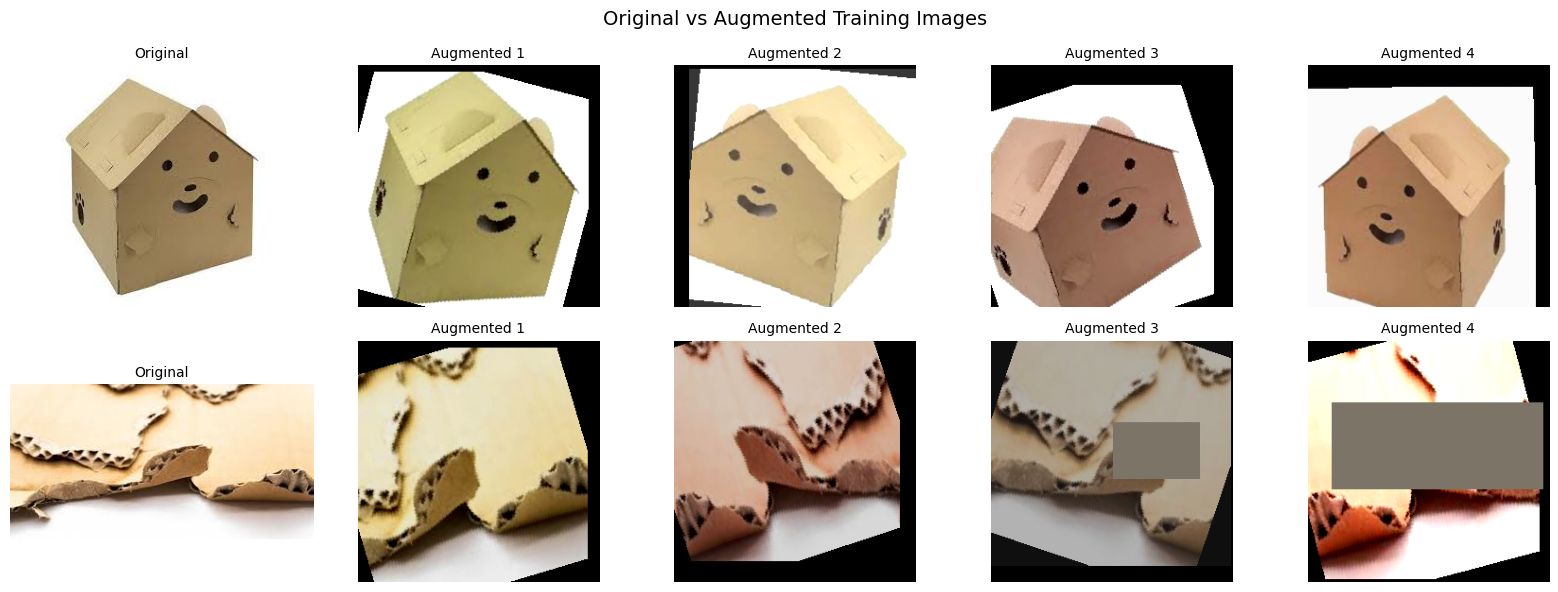

In [28]:
# training transforms include augmentation to reduce overfitting
# test transforms are deterministic with no augmentation
# imagenet normalisation matches what resnet18 was pretrained on

IMG_SIZE = 256
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.Resize((288, 288)),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=20),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.2),
])

test_transforms = T.Compose([
    T.Resize((288, 288)),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# show original vs augmented examples
fig, axes = plt.subplots(2, 5, figsize=(16, 6))

sample_img = Image.open(train_files[0]).convert('RGB')
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title('Original', fontsize=10)
axes[0, 0].axis('off')

# show the same image with different random augmentations
for i in range(1, 5):
    aug_tensor = train_transforms(sample_img)
    # undo normalisation for display
    aug_display = aug_tensor.clone()
    for c in range(3):
        aug_display[c] = aug_display[c] * IMAGENET_STD[c] + IMAGENET_MEAN[c]
    aug_display = aug_display.clamp(0, 1)
    axes[0, i].imshow(aug_display.permute(1, 2, 0).numpy())
    axes[0, i].set_title(f'Augmented {i}', fontsize=10)
    axes[0, i].axis('off')

sample_img2 = Image.open(train_files[100]).convert('RGB')
axes[1, 0].imshow(sample_img2)
axes[1, 0].set_title('Original', fontsize=10)
axes[1, 0].axis('off')

for i in range(1, 5):
    aug_tensor = train_transforms(sample_img2)
    aug_display = aug_tensor.clone()
    for c in range(3):
        aug_display[c] = aug_display[c] * IMAGENET_STD[c] + IMAGENET_MEAN[c]
    aug_display = aug_display.clamp(0, 1)
    axes[1, i].imshow(aug_display.permute(1, 2, 0).numpy())
    axes[1, i].set_title(f'Augmented {i}', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('Original vs Augmented Training Images', fontsize=14)
plt.tight_layout()
plt.show()


## Dataset, DataLoader and Train/Val Split

- A custom `RecyclingDataset` class loads images from file paths on-the-fly and applies transforms at access time; this avoids pre-loading the entire image dataset into RAM, which is impractical for larger datasets and inflexible when experimenting with different transforms
- The 85/15 stratified split preserves class proportions in both train and validation sets; with imbalanced classes, a random split could result in validation containing very few examples of minority classes, producing unreliable validation F1 during training
- `BATCH_SIZE=32` balances GPU memory usage with gradient stability; larger batches are more memory-efficient but can lead to sharper minima; smaller batches add gradient noise which sometimes helps regularisation but slows convergence
- DataLoader `shuffle=True` for training ensures the model sees different class orderings each epoch, preventing it from learning epoch-level ordering patterns
- `num_workers=0` is required for Windows Jupyter compatibility — Windows cannot fork subprocess workers for PyTorch DataLoaders in notebook environments; set to a higher value (e.g. 4) on Linux or macOS for faster data loading

In [29]:
# custom dataset that loads images and applies transforms
# stratified split keeps class proportions consistent

class RecyclingDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.file_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# label encoding
classes = sorted(set(train_labels))
label2id = {c: i for i, c in enumerate(classes)}
id2label = {i: c for c, i in label2id.items()}
NUM_CLASSES = len(classes)

train_encoded = [label2id[l] for l in train_labels]
test_encoded = [label2id[l] for l in test_labels]

print(f"Label mapping: {label2id}")
print(f"Number of classes: {NUM_CLASSES}")

# stratified train/val split
train_idx, val_idx = train_test_split(
    range(len(train_files)),
    test_size=0.15,
    stratify=train_encoded,
    random_state=SEED
)

train_split_files = [train_files[i] for i in train_idx]
train_split_labels = [train_encoded[i] for i in train_idx]
val_split_files = [train_files[i] for i in val_idx]
val_split_labels = [train_encoded[i] for i in val_idx]

print(f"\nTrain: {len(train_split_files)}")
print(f"Val:   {len(val_split_files)}")
print(f"Test:  {len(test_files)}")

# create datasets and dataloaders
# num_workers=0 because windows multiprocessing hangs in jupyter
BATCH_SIZE = 32

train_dataset = RecyclingDataset(train_split_files, train_split_labels, train_transforms)
val_dataset = RecyclingDataset(val_split_files, val_split_labels, test_transforms)
test_dataset = RecyclingDataset(test_files, test_encoded, test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=0, pin_memory=True)

# verify a batch
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Label mapping: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Number of classes: 6

Train: 3387
Val:   598
Test:  1704

Batch shape: torch.Size([32, 3, 256, 256])
Labels shape: torch.Size([32])


## Majority Class Baseline

- The simplest possible classifier predicts the most common class (glass) for every input image, regardless of its content
- This establishes the absolute performance floor: any useful model must substantially exceed this score; on a 6-class problem with glass being the most frequent class, the majority classifier achieves roughly 25% accuracy and negligible macro F1
- Low baseline macro F1 confirms that class imbalance is present and meaningful — a model achieving 93%+ macro F1 after training demonstrates a genuine 80+ percentage point improvement over the floor, not an artificially inflated result relative to an easy task
- Comparing against this baseline at each stage of the pipeline makes the contribution of transfer learning immediately visible

In [30]:
# majority class baseline — always predicts the most frequent class (glass)
# sets the absolute performance floor; any useful model must substantially exceed this

majority_class = max(set(train_split_labels), key=train_split_labels.count)
majority_preds = [majority_class] * len(test_encoded)

majority_acc = accuracy_score(test_encoded, majority_preds)
majority_f1 = f1_score(test_encoded, majority_preds, average='macro')

print(f"Majority class: {id2label[majority_class]}")
print(f"Accuracy: {majority_acc:.4f}")
print(f"Macro F1: {majority_f1:.4f}")

Majority class: glass
Accuracy: 0.2512
Macro F1: 0.0669


## ResNet-18 Model Setup — Transfer Learning

- Transfer learning reuses weights pretrained on ImageNet (1.2M labelled images, 1000 classes) as the starting point for material classification; the pretrained network has already learned to detect low-level visual features (edges, colour gradients, textures) and progressively higher-level patterns (shapes, object parts) that are directly relevant to distinguishing material surfaces
- ResNet-18 is chosen over larger variants (ResNet-50, ResNet-101) because the training set is relatively small (~3,985 images); deeper models have more parameters and are more prone to overfitting on small datasets; ResNet-18 with transfer learning is a well-validated choice for small-data image classification
- The original 1000-class ImageNet head is replaced with a new classification head: `Dropout(0.3) → Linear(512, 6)`; `Dropout(0.3)` before the final layer acts as regularisation, preventing the head from over-relying on any single feature
- FocalLoss (Lin et al., 2017) is chosen over standard cross-entropy because it dynamically down-weights easy, well-classified examples and concentrates gradient signal on hard borderline cases; without focal loss the model would optimise mainly for the dominant glass class at the expense of harder minority categories
- `gamma=2.0` is the standard value from the original focal loss paper; class weights (inverse frequency) provide additional compensation for glass overrepresentation on top of the focal modulation
- Parameter count is printed to provide a reference for comparison with ResNet-50 in the model comparison section

In [31]:
# load pretrained resnet18 and replace the classification head
# pretrained weights provide ImageNet feature detectors as a strong starting point
# new head: Dropout(0.3) -> Linear(512, 6); FocalLoss handles glass class imbalance
# add dropout before the final linear layer for regularisation

model = models.resnet18(weights='IMAGENET1K_V1')

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, NUM_CLASSES)
)

model = model.to(device)

# parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# focal loss handles class imbalance by focusing on hard examples
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing
    
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(
            inputs, targets,
            weight=self.weight,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# class weights from inverse frequency
class_counts = Counter(train_split_labels)
total = sum(class_counts.values())
class_weights = torch.tensor(
    [total / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)

print(f"\nClass weights: {dict(zip(classes, class_weights.cpu().numpy().round(3)))}")

Total parameters:     11,179,590
Trainable parameters: 11,179,590

Class weights: {'cardboard': np.float32(1.075), 'glass': np.float32(0.665), 'metal': np.float32(1.266), 'paper': np.float32(0.913), 'plastic': np.float32(1.122), 'trash': np.float32(1.266)}


## Phase 1: Classification Head Training Only

- Progressive unfreezing starts by training only the randomly-initialised classification head while the entire ResNet backbone is frozen; the motivation is mechanical — a randomly initialised head produces large, noisy gradient updates in the first few batches, and backpropagating these through the pretrained backbone would corrupt the ImageNet feature representations that took millions of training images to build
- Freezing the backbone (`param.requires_grad = False` on all backbone parameters) blocks these destructive gradients from reaching the pretrained layers; Phase 1 is a controlled warm-up that brings the head to a sensible starting point before full fine-tuning
- BatchNorm layers are additionally set to `eval()` mode during Phase 1; BatchNorm in training mode updates its running mean and variance statistics with each mini-batch — allowing this on a small recycling dataset would corrupt the stable ImageNet statistics accumulated during pretraining, introducing a secondary form of feature damage
- A higher learning rate (lr=1e-3) is appropriate because only the small classification head (~262K parameters) is being updated; there is no risk of damaging the frozen backbone, so aggressive head learning is both safe and fast
- The best checkpoint by validation F1 is saved to disk so Phase 2 starts from the strongest head initialisation regardless of whether the final Phase 1 epoch was the best

In [32]:
# phase 1: freeze backbone, train only classification head
# frozen backbone prevents random head gradients from corrupting pretrained features
# batchnorm set to eval to preserve ImageNet statistics; lr=1e-3 safe for head only
# batchnorm layers set to eval to preserve imagenet running stats

PHASE1_EPOCHS = 5

# freeze everything except the fc head
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 1 — Trainable parameters: {trainable:,}")

optimizer = optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=0.01)
criterion = FocalLoss(weight=class_weights, gamma=2.0)
scaler = GradScaler()

# track metrics across both phases
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [], 'val_f1': []
}

best_val_f1 = 0.0

for epoch in range(PHASE1_EPOCHS):
    # training
    model.train()
    # keep batchnorm in eval mode to preserve imagenet stats
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
            m.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    
    train_loss = running_loss / total
    train_acc = correct / total
    
    # validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    
    val_loss /= val_total
    val_acc = val_correct / val_total
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    star = ' ★' if val_f1 > best_val_f1 else ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model_phase1.pth')
    
    print(f"Epoch {epoch+1}/{PHASE1_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f}{star}")

print(f"\nBest Phase 1 Val F1: {best_val_f1:.4f}")

Phase 1 — Trainable parameters: 3,078


C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\3158836141.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\3158836141.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/5 | Train Loss: 0.8762 | Train Acc: 0.4588 | Val Loss: 0.4129 | Val Acc: 0.7023 | Val F1: 0.7115 ★


C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\3158836141.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 2/5 | Train Loss: 0.5491 | Train Acc: 0.6392 | Val Loss: 0.3074 | Val Acc: 0.7809 | Val F1: 0.7842 ★


C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\3158836141.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 3/5 | Train Loss: 0.4790 | Train Acc: 0.6800 | Val Loss: 0.2745 | Val Acc: 0.8043 | Val F1: 0.8073 ★


C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\3158836141.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


KeyboardInterrupt: 

## Phase 2: Full Fine-tuning with Differential Learning Rates

- After Phase 1 establishes a stable head, the backbone is unfrozen for end-to-end fine-tuning; all layers now adapt together, allowing the backbone's feature detectors to specialise for material texture and surface appearance rather than general-purpose ImageNet features
- Differential learning rates are the central design decision: backbone layers use `lr=2e-5` (very conservative) while the classification head uses `lr=2e-4` (10× higher); lower rates for pretrained layers preserve the general visual representations while allowing targeted task-specific adaptation — using a single learning rate high enough for the head would destroy the pretrained backbone (catastrophic forgetting)
- Separate parameter groups for bias and BatchNorm parameters have weight decay set to 0.0; applying L2 regularisation to these parameters degrades performance in CNN fine-tuning and is the standard practice to exclude them
- OneCycleLR scheduler warms up from a fraction of `max_lr` over the first 10% of total steps, then cosine-anneals to near zero; the warm-up prevents instability at the start of fine-tuning when all parameters are suddenly in play; cosine annealing tends to find flatter minima that generalise better than constant learning rate
- Early stopping with patience=5 halts training when validation F1 has not improved for 5 consecutive epochs; this prevents overfitting on the relatively small training set while allowing enough time for the model to plateau naturally
- FocalLoss with `label_smoothing=0.1` smooths the target distribution, preventing overconfident predictions and improving calibration — particularly useful for boundary cases between visually similar materials such as transparent plastic and glass
- Gradient clipping (`max_norm=1.0`) prevents occasional exploding gradient updates from destabilising the OneCycleLR schedule

In [ ]:
# phase 2: unfreeze all layers and fine-tune end to end
# differential learning rates protect pretrained features
# label smoothing improves calibration

PHASE2_EPOCHS = 25
PATIENCE = 5

# load best phase 1 checkpoint
model.load_state_dict(torch.load('best_model_phase1.pth'))

# unfreeze everything
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 2 — All trainable: {trainable:,}")

# differential learning rates
# no weight decay on bias and batchnorm params
backbone_params = []
backbone_params_no_decay = []
head_params = []
head_params_no_decay = []

for name, param in model.named_parameters():
    if 'fc' in name:
        if 'bias' in name:
            head_params_no_decay.append(param)
        else:
            head_params.append(param)
    else:
        if 'bias' in name or 'bn' in name:
            backbone_params_no_decay.append(param)
        else:
            backbone_params.append(param)

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': 2e-5, 'weight_decay': 0.01},
    {'params': backbone_params_no_decay, 'lr': 2e-5, 'weight_decay': 0.0},
    {'params': head_params, 'lr': 2e-4, 'weight_decay': 0.01},
    {'params': head_params_no_decay, 'lr': 2e-4, 'weight_decay': 0.0},
])

total_steps = PHASE2_EPOCHS * len(train_loader)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[2e-5, 2e-5, 2e-4, 2e-4],
    total_steps=total_steps,
    pct_start=0.1,
    anneal_strategy='cos'
)

criterion = FocalLoss(weight=class_weights, gamma=2.0, label_smoothing=0.1)
scaler = GradScaler()

best_val_f1 = max(history['val_f1'])
patience_counter = 0

for epoch in range(PHASE2_EPOCHS):
    # training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    
    train_loss = running_loss / total
    train_acc = correct / total
    
    # validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    
    val_loss /= val_total
    val_acc = val_correct / val_total
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    star = ' ★' if val_f1 > best_val_f1 else ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model_final.pth')
        patience_counter = 0
    else:
        patience_counter += 1
    
    print(f"Epoch {epoch+1}/{PHASE2_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f}{star}")
    
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest Phase 2 Val F1: {best_val_f1:.4f}")

Phase 2 — All trainable: 11,179,590


C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\2328263362.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model_phase1.pth'))
C

Epoch 1/25 | Train Loss: 0.7025 | Train Acc: 0.6309 | Val Loss: 0.4335 | Val Acc: 0.7776 | Val F1: 0.7743


C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\2328263362.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 2/25 | Train Loss: 0.5632 | Train Acc: 0.6867 | Val Loss: 0.3302 | Val Acc: 0.8579 | Val F1: 0.8579 ★


...

Epoch 20/25 | Train Loss: 0.1716 | Train Acc: 0.9436 | Val Loss: 0.2038 | Val Acc: 0.9214 | Val F1: 0.9214


C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\2328263362.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 21/25 | Train Loss: 0.1663 | Train Acc: 0.9442 | Val Loss: 0.2020 | Val Acc: 0.9247 | Val F1: 0.9249


C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\2328263362.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 22/25 | Train Loss: 0.1702 | Train Acc: 0.9404 | Val Loss: 0.2021 | Val Acc: 0.9247 | Val F1: 0.9250

Early stopping at epoch 22

Best Phase 2 Val F1: 0.9316


## Training Curves

- Training and validation loss, accuracy, and macro F1 are plotted across all epochs from both phases to give a visual health check of the training process
- A large persistent gap between train and validation metrics indicates overfitting — the model is memorising the training set rather than generalising; increasing augmentation strength or reducing model capacity are the primary interventions
- The Phase 1→2 boundary is marked with a vertical dashed line; the typical signature when unfreezing the backbone is a visible inflection point where validation metrics improve more steeply — confirming that end-to-end fine-tuning adds value beyond head-only training
- Validation F1 peaking and flattening before all epochs complete confirms that early stopping is engaging at an appropriate point

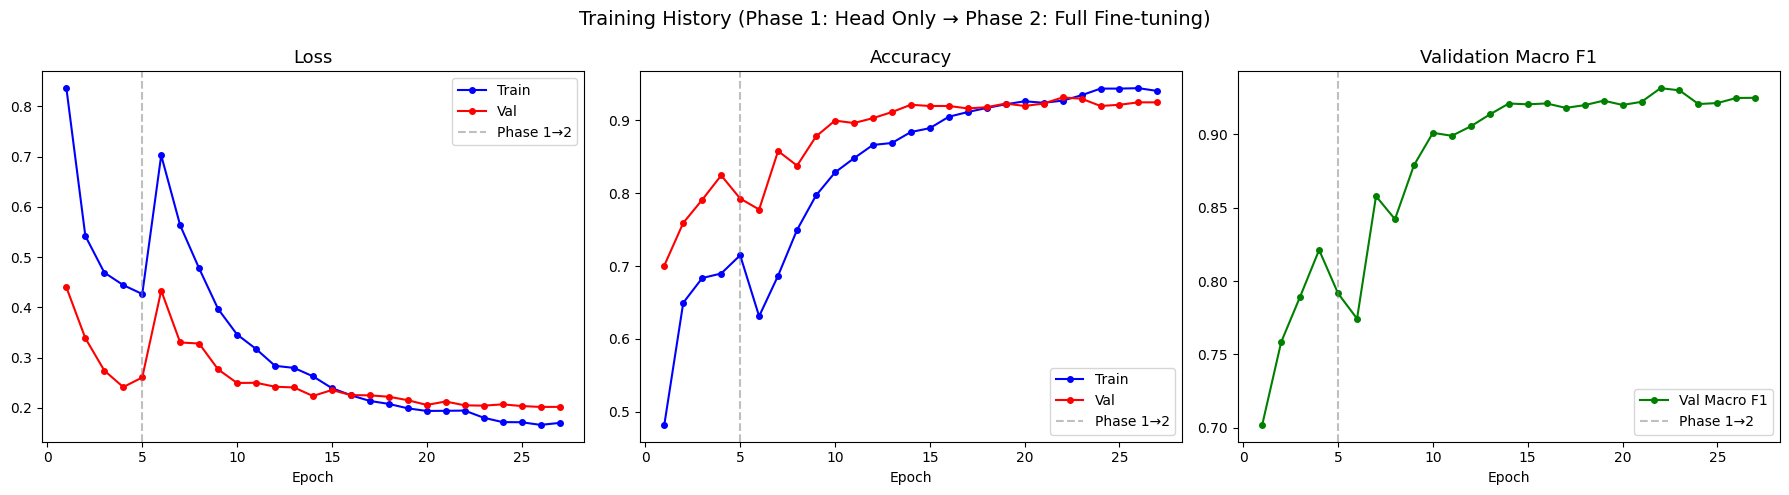

In [ ]:
# training curves across both phases
# phase boundary marked to show the effect of unfreezing — visible inflection expected
# diverging train/val gap indicates overfitting; flat convergence indicates plateau

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)
phase1_end = PHASE1_EPOCHS

# loss
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train', markersize=4)
axes[0].plot(epochs_range, history['val_loss'], 'r-o', label='Val', markersize=4)
axes[0].axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.5, label='Phase 1→2')
axes[0].set_title('Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].legend()

# accuracy
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train', markersize=4)
axes[1].plot(epochs_range, history['val_acc'], 'r-o', label='Val', markersize=4)
axes[1].axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.5, label='Phase 1→2')
axes[1].set_title('Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].legend()

# macro f1
axes[2].plot(epochs_range, history['val_f1'], 'g-o', label='Val Macro F1', markersize=4)
axes[2].axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.5, label='Phase 1→2')
axes[2].set_title('Validation Macro F1', fontsize=13)
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('Training History (Phase 1: Head Only → Phase 2: Full Fine-tuning)', fontsize=14)
plt.tight_layout()
plt.show()

## Test Set Evaluation

- The held-out test set is evaluated exactly once, after all training decisions and hyperparameter choices are finalised using validation metrics only; any earlier use of test data would constitute information leakage and inflate reported metrics
- **Accuracy** is the fraction of correctly classified images — straightforward but misleading when classes are imbalanced; the glass-heavy distribution means a model could achieve ~25% accuracy by always predicting glass without learning anything useful
- **Macro F1** is the primary metric — it computes F1 separately for each of the 6 classes and averages them equally regardless of class frequency; this means performance on the smallest class (metal, plastic) matters as much as on glass; a recycling system that works well on common materials but fails on rarer ones is not production-ready
- **Weighted F1** weights each class by its test-set support — useful for understanding overall system throughput but can mask poor performance on minority classes
- **MCC (Matthews Correlation Coefficient)** is a single value in [−1, 1] that accounts for all cells of the confusion matrix simultaneously; it is considered the most informative single metric for multi-class classification with class imbalance, less prone to optimistic bias than accuracy or F1 in isolation
- The confusion matrix shows which class pairs are most frequently confused — this directly identifies where the model is uncertain and where additional training data or augmentation would help most

C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\3077145980.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model_final.pth'))


TEST SET RESULTS
Accuracy:        0.9249
Macro F1:        0.9228
Weighted F1:     0.9251
MCC:             0.9093

Per-class Breakdown:
              precision    recall  f1-score   support

   cardboard       0.97      0.95      0.96       264
       glass       0.96      0.90      0.93       428
       metal       0.84      0.99      0.91       225
       paper       0.95      0.95      0.95       311
     plastic       0.89      0.87      0.88       252
       trash       0.92      0.90      0.91       224

    accuracy                           0.92      1704
   macro avg       0.92      0.93      0.92      1704
weighted avg       0.93      0.92      0.93      1704



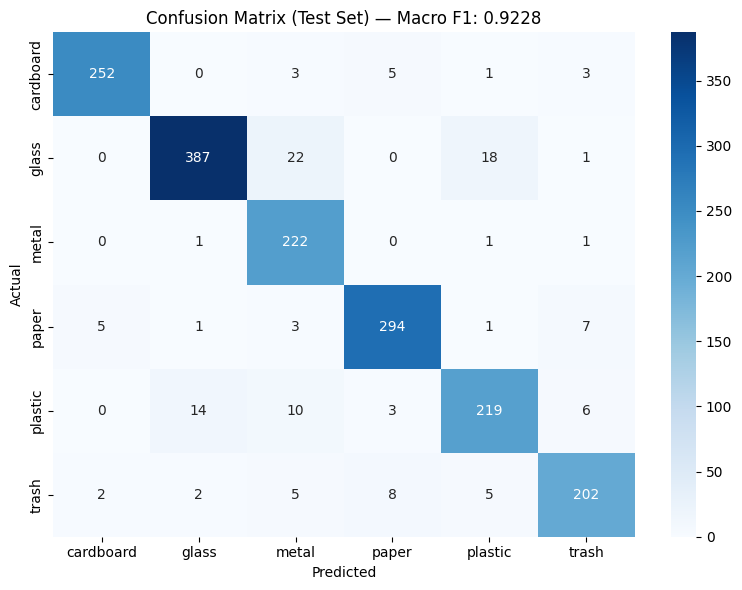


=== Model Comparison ===
Model                          Accuracy     Macro F1    
------------------------------------------------------
Majority Class                 0.2512       0.0669      
ResNet-18 (Fine-tuned)         0.9249       0.9228      


In [ ]:
# load best model and evaluate on test set
# single evaluation on held-out data; macro F1 is primary metric (equal weight per class)
# MCC accounts for all confusion matrix cells — robust to class imbalance

model.load_state_dict(torch.load('best_model_final.pth'))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=-1)
        
        all_preds.extend(outputs.argmax(dim=-1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)

# metrics
test_acc = accuracy_score(all_labels, all_preds)
test_f1_macro = f1_score(all_labels, all_preds, average='macro')
test_f1_weighted = f1_score(all_labels, all_preds, average='weighted')
test_mcc = matthews_corrcoef(all_labels, all_preds)

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Accuracy:        {test_acc:.4f}")
print(f"Macro F1:        {test_f1_macro:.4f}")
print(f"Weighted F1:     {test_f1_weighted:.4f}")
print(f"MCC:             {test_mcc:.4f}")
print(f"\n{'=' * 60}")
print("Per-class Breakdown:")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=classes))

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Test Set) — Macro F1: {test_f1_macro:.4f}')
plt.tight_layout()
plt.show()

# model comparison
print("\n=== Model Comparison ===")
print(f"{'Model':<30} {'Accuracy':<12} {'Macro F1':<12}")
print("-" * 54)
print(f"{'Majority Class':<30} {majority_acc:<12.4f} {majority_f1:<12.4f}")
print(f"{'ResNet-18 (Fine-tuned)':<30} {test_acc:<12.4f} {test_f1_macro:<12.4f}")

## Model Comparison — ResNet-18 vs ResNet-50

- To determine whether a deeper architecture improves performance on this dataset, ResNet-50 V2 is trained with the identical pipeline
- ResNet-50 has approximately 25M backbone parameters versus ResNet-18's 11M; the deeper network can learn more complex feature hierarchies, but the benefit on small datasets is not guaranteed — more parameters also means more overfitting risk
- V2 weights (IMAGENET1K_V2) are used rather than V1; the V2 training recipe achieved 80.9% top-1 ImageNet accuracy vs V1's 76.1% using improved augmentation, label smoothing, and longer pretraining schedules — a stronger starting point without changing the architecture
- Both models use the same head structure (Dropout 0.3 → Linear), the same focal loss, class weights, learning rates (backbone 2e-5, head 2e-4), early stopping patience, and evaluation protocol; any performance difference is attributable to architecture and pretraining, not pipeline differences
- The winner is loaded as the active `model` going forward for TTA and inference

In [ ]:
# ResNet-50 V2 training with identical pipeline to optimised ResNet-18
# -----------------------------------------------------------------
# Load fresh ResNet-50 with IMAGENET1K_V2 weights

resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Replace head: same structure as ResNet-18 (dropout 0.3 + linear)
in_features_50 = resnet50.fc.in_features
resnet50.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features_50, len(classes))
)
resnet50 = resnet50.to(device)

total50 = sum(p.numel() for p in resnet50.parameters())
total18 = sum(p.numel() for p in model.parameters())
print(f"ResNet-18 parameters: {total18:,}")
print(f"ResNet-50 parameters: {total50:,}")

# ── Phase 1: head only ────────────────────────────────────────────
P1_EPOCHS_50 = 5

for param in resnet50.parameters():
    param.requires_grad = False
for param in resnet50.fc.parameters():
    param.requires_grad = True

optimizer50_p1 = optim.AdamW(resnet50.fc.parameters(), lr=1e-3, weight_decay=0.01)
criterion50 = FocalLoss(weight=class_weights, gamma=2.0, label_smoothing=0.1)
scaler50 = GradScaler()

best_p1_f1_50 = 0.0
for epoch in range(P1_EPOCHS_50):
    resnet50.train()
    # freeze batchnorm layers in backbone
    for m in resnet50.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()

    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer50_p1.zero_grad()
        with autocast():
            outputs = resnet50(images)
            loss = criterion50(outputs, labels)
        scaler50.scale(loss).backward()
        scaler50.step(optimizer50_p1)
        scaler50.update()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    # validation
    resnet50.eval()
    val_preds_50, val_labels_50 = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet50(images)
            _, preds = outputs.max(1)
            val_preds_50.extend(preds.cpu().tolist())
            val_labels_50.extend(labels.cpu().tolist())
    val_f1_50 = f1_score(val_labels_50, val_preds_50, average='macro')
    if val_f1_50 > best_p1_f1_50:
        best_p1_f1_50 = val_f1_50
        torch.save(resnet50.state_dict(), 'best_model_resnet50_phase1.pth')
    print(f"ResNet-50 Phase 1 Epoch {epoch+1}/{P1_EPOCHS_50} | "
          f"Train Loss: {running_loss/total:.4f} | Val F1: {val_f1_50:.4f}")

# ── Phase 2: full fine-tune ───────────────────────────────────────
P2_EPOCHS_50 = 25
PATIENCE_50  = 5

resnet50.load_state_dict(torch.load('best_model_resnet50_phase1.pth'))
for param in resnet50.parameters():
    param.requires_grad = True

bb_p, bb_p_nd, hd_p, hd_p_nd = [], [], [], []
for name, param in resnet50.named_parameters():
    if 'fc' in name:
        if 'bias' in name:
            hd_p_nd.append(param)
        else:
            hd_p.append(param)
    else:
        if 'bias' in name or 'bn' in name:
            bb_p_nd.append(param)
        else:
            bb_p.append(param)

optimizer50 = optim.AdamW([
    {'params': bb_p,    'lr': 2e-5, 'weight_decay': 0.01},
    {'params': bb_p_nd, 'lr': 2e-5, 'weight_decay': 0.0},
    {'params': hd_p,    'lr': 2e-4, 'weight_decay': 0.01},
    {'params': hd_p_nd, 'lr': 2e-4, 'weight_decay': 0.0},
])
total_steps_50 = P2_EPOCHS_50 * len(train_loader)
scheduler50 = optim.lr_scheduler.OneCycleLR(
    optimizer50,
    max_lr=[2e-5, 2e-5, 2e-4, 2e-4],
    total_steps=total_steps_50,
    pct_start=0.1,
    anneal_strategy='cos'
)

best_val_f1_50 = best_p1_f1_50
patience_counter_50 = 0

for epoch in range(P2_EPOCHS_50):
    resnet50.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer50.zero_grad()
        with autocast():
            outputs = resnet50(images)
            loss = criterion50(outputs, labels)
        scaler50.scale(loss).backward()
        scaler50.unscale_(optimizer50)
        nn.utils.clip_grad_norm_(resnet50.parameters(), max_norm=1.0)
        scaler50.step(optimizer50)
        scaler50.update()
        scheduler50.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    resnet50.eval()
    val_preds_50, val_labels_50 = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet50(images)
            _, preds = outputs.max(1)
            val_preds_50.extend(preds.cpu().tolist())
            val_labels_50.extend(labels.cpu().tolist())
    val_f1_50 = f1_score(val_labels_50, val_preds_50, average='macro')

    star = ' ★' if val_f1_50 > best_val_f1_50 else ''
    if val_f1_50 > best_val_f1_50:
        best_val_f1_50 = val_f1_50
        torch.save(resnet50.state_dict(), 'best_model_resnet50.pth')
        patience_counter_50 = 0
    else:
        patience_counter_50 += 1

    print(f"ResNet-50 Phase 2 Epoch {epoch+1}/{P2_EPOCHS_50} | "
          f"Train Loss: {running_loss/total:.4f} | Val F1: {val_f1_50:.4f}{star}")

    if patience_counter_50 >= PATIENCE_50:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# ── Evaluate ResNet-50 on test set ───────────────────────────────
resnet50.load_state_dict(torch.load('best_model_resnet50.pth'))
resnet50.eval()

preds_50, labels_50, probs_50 = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet50(images)
        p = torch.softmax(outputs, dim=-1)
        preds_50.extend(outputs.argmax(dim=-1).cpu().tolist())
        labels_50.extend(labels.cpu().tolist())
        probs_50.extend(p.cpu().numpy())

probs_50 = np.array(probs_50)
acc_50    = accuracy_score(labels_50, preds_50)
f1_50     = f1_score(labels_50, preds_50, average='macro')
mcc_50    = matthews_corrcoef(labels_50, preds_50)

print("\n" + "=" * 60)
print("ResNet-50 TEST RESULTS")
print("=" * 60)
print(f"Accuracy:   {acc_50:.4f}")
print(f"Macro F1:   {f1_50:.4f}")
print(f"MCC:        {mcc_50:.4f}")

# ── Side-by-side comparison ───────────────────────────────────────
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Model':<30} {'Accuracy':<12} {'Macro F1':<12} {'MCC':<10}")
print("-" * 64)
print(f"{'ResNet-18 (optimised)':<30} {test_acc:<12.4f} {test_f1_macro:<12.4f} {test_mcc:<10.4f}")
print(f"{'ResNet-50 V2 (optimised)':<30} {acc_50:<12.4f} {f1_50:<12.4f} {mcc_50:<10.4f}")

# ── Keep whichever scored higher as final model ───────────────────
if f1_50 > test_f1_macro:
    print("\n→ ResNet-50 wins. Loading ResNet-50 as final model.")
    model = resnet50
    final_model_f1  = f1_50
    final_model_acc = acc_50
    final_model_mcc = mcc_50
    final_model_name = 'ResNet-50 V2 (optimised)'
    final_all_preds  = preds_50
    final_all_labels = labels_50
    final_all_probs  = probs_50
else:
    print("\n→ ResNet-18 wins. Keeping ResNet-18 as final model.")
    final_model_f1  = test_f1_macro
    final_model_acc = test_acc
    final_model_mcc = test_mcc
    final_model_name = 'ResNet-18 (optimised)'
    final_all_preds  = all_preds
    final_all_labels = all_labels
    final_all_probs  = all_probs


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\xmaxm/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:08<00:00, 11.8MB/s]
C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\234453444.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler50 = GradScaler()
C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\234453444.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


ResNet-18 parameters: 11,179,590
ResNet-50 parameters: 23,520,326
ResNet-50 Phase 1 Epoch 1/5 | Train Loss: 0.6362 | Val F1: 0.8730


C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\234453444.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


ResNet-50 Phase 1 Epoch 2/5 | Train Loss: 0.3761 | Val F1: 0.8933


C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\234453444.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

ResNet-50 Phase 2 Epoch 20/25 | Train Loss: 0.1073 | Val F1: 0.9657


C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\234453444.py:117: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


ResNet-50 Phase 2 Epoch 21/25 | Train Loss: 0.1025 | Val F1: 0.9634

Early stopping at epoch 21


C:\Users\xmaxm\AppData\Local\Temp\ipykernel_37832\234453444.py:158: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet50.load_state_dict(torch.load('best_model_resnet50.pt


ResNet-50 TEST RESULTS
Accuracy:   0.9513
Macro F1:   0.9490
MCC:        0.9410

MODEL COMPARISON
Model                          Accuracy     Macro F1     MCC       
----------------------------------------------------------------
ResNet-18 (optimised)          0.9249       0.9228       0.9093    
ResNet-50 V2 (optimised)       0.9513       0.9490       0.9410    

→ ResNet-50 wins. Loading ResNet-50 as final model.


## Test-Time Augmentation

- Test-Time Augmentation (TTA) averages the model's softmax probability predictions across multiple augmented views of the same test image at inference time; no retraining or weight update is involved
- The intuition: each augmented view exposes slightly different visual features, and averaging across views reduces variance in the probability estimates — the model cannot get unlucky with a single crop or orientation that happens to be hard to classify
- Four transform variants are used:
  - **Standard test transform**: the baseline deterministic view (resize 288 → crop 256)
  - **Horizontally flipped**: mirrors the image; material class is invariant to horizontal flip
  - **Larger crop (resize 320 → crop 256)**: a slightly zoomed-in view emphasising central features
  - **Smaller crop (resize 256 → crop 256)**: a slightly zoomed-out view with more surrounding context
- The four softmax probability vectors are summed and divided by 4; the argmax of the mean vector is the TTA prediction
- TTA provides a free accuracy improvement with no model changes — the only cost is running the forward pass 4× per image instead of 1×, which is an acceptable trade-off for better accuracy in a batch-inference scenario

In [ ]:
# Test-Time Augmentation (TTA)
# Average softmax probabilities over 4 augmented views of each test image

tta_transforms = [
    # 1. Standard test transform
    T.Compose([
        T.Resize((288, 288)),
        T.CenterCrop(IMG_SIZE),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    # 2. Horizontally flipped
    T.Compose([
        T.Resize((288, 288)),
        T.CenterCrop(IMG_SIZE),
        T.RandomHorizontalFlip(p=1.0),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    # 3. Larger crop (resize 320 → crop 256)
    T.Compose([
        T.Resize((320, 320)),
        T.CenterCrop(IMG_SIZE),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    # 4. Smaller crop (resize 256 → crop 256)
    T.Compose([
        T.Resize((256, 256)),
        T.CenterCrop(IMG_SIZE),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
]

from torch.utils.data import DataLoader as DL

# RecyclingDataset uses whatever transform is passed at construction time
# so we temporarily swap the transform for each TTA variant
tta_probs_accum = None

for t_idx, tta_tfm in enumerate(tta_transforms):
    # build a temporary dataset/loader with this transform
    tta_dataset = RecyclingDataset(test_files, test_encoded, transform=tta_tfm)
    tta_loader  = DL(tta_dataset, batch_size=32, shuffle=False, num_workers=0)

    model.eval()
    batch_probs = []
    with torch.no_grad():
        for images, _ in tta_loader:
            images = images.to(device)
            outputs = model(images)
            p = torch.softmax(outputs, dim=-1)
            batch_probs.extend(p.cpu().numpy())

    batch_probs = np.array(batch_probs)
    if tta_probs_accum is None:
        tta_probs_accum = batch_probs
    else:
        tta_probs_accum += batch_probs

    print(f"TTA view {t_idx+1}/4 complete")

# average over 4 views
tta_probs_mean = tta_probs_accum / len(tta_transforms)
tta_preds      = tta_probs_mean.argmax(axis=1).tolist()

# ground truth labels (same order as test_loader — no shuffle)
tta_labels = []
plain_dataset = RecyclingDataset(test_files, test_encoded, transform=test_transforms)
plain_loader  = DL(plain_dataset, batch_size=32, shuffle=False, num_workers=0)
for _, labels in plain_loader:
    tta_labels.extend(labels.tolist())

tta_acc = accuracy_score(tta_labels, tta_preds)
tta_f1  = f1_score(tta_labels, tta_preds, average='macro')
tta_mcc = matthews_corrcoef(tta_labels, tta_preds)

print("\n" + "=" * 60)
print("TTA RESULTS")
print("=" * 60)
print(f"Accuracy:   {tta_acc:.4f}  (Δ {tta_acc - final_model_acc:+.4f})")
print(f"Macro F1:   {tta_f1:.4f}  (Δ {tta_f1  - final_model_f1:+.4f})")
print(f"MCC:        {tta_mcc:.4f}  (Δ {tta_mcc - final_model_mcc:+.4f})")

print("\n" + "=" * 60)
print("WITHOUT TTA vs WITH TTA")
print("=" * 60)
print(f"{'Model':<35} {'Accuracy':<12} {'Macro F1':<12} {'MCC':<10}")
print("-" * 69)
print(f"{final_model_name + ' (no TTA)':<35} {final_model_acc:<12.4f} {final_model_f1:<12.4f} {final_model_mcc:<10.4f}")
print(f"{final_model_name + ' + TTA':<35} {tta_acc:<12.4f} {tta_f1:<12.4f} {tta_mcc:<10.4f}")


TTA view 1/4 complete
TTA view 2/4 complete
TTA view 3/4 complete
TTA view 4/4 complete

TTA RESULTS
Accuracy:   0.9572  (Δ +0.0059)
Macro F1:   0.9548  (Δ +0.0058)
MCC:        0.9481  (Δ +0.0071)

WITHOUT TTA vs WITH TTA
Model                               Accuracy     Macro F1     MCC       
---------------------------------------------------------------------
ResNet-50 V2 (optimised) (no TTA)   0.9513       0.9490       0.9410    
ResNet-50 V2 (optimised) + TTA      0.9572       0.9548       0.9481    


## ROC Curves

- ROC (Receiver Operating Characteristic) curves plot true positive rate against false positive rate across all possible decision thresholds, evaluated in a one-vs-rest formulation for each of the 6 material classes
- AUC (Area Under the Curve) summarises threshold-independent discrimination quality: AUC=1.0 means the model perfectly separates a class from all others at some threshold; AUC=0.5 means random chance; near-perfect AUC across all 6 classes confirms the model's softmax probabilities are well-ordered and usable as confidence signals
- High AUC is practically important for a recycling sorting system: per-class confidence thresholds could be used to flag low-confidence items for human review rather than forcing a classification on uncertain borderline examples

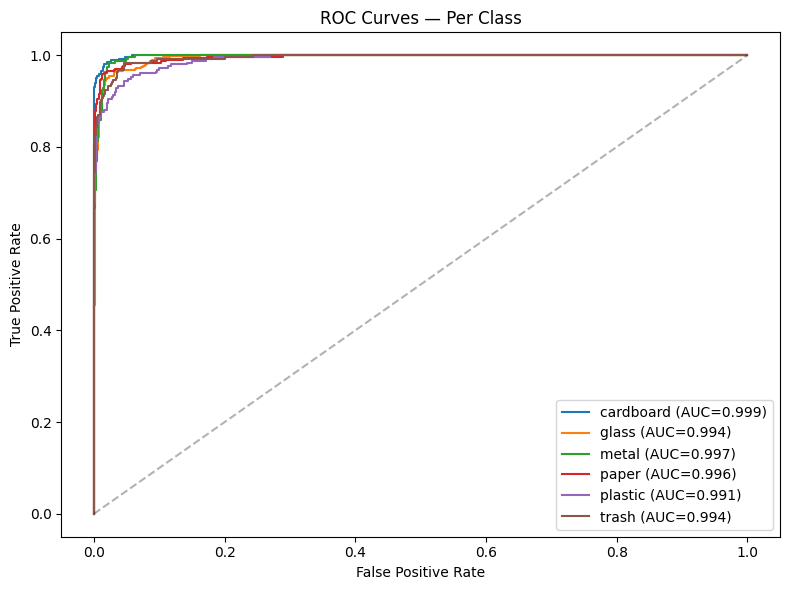

In [ ]:
# roc curves per class — one-vs-rest AUC for each material category
# near-perfect AUC confirms probabilities are well-ordered for confidence thresholding

fig, ax = plt.subplots(figsize=(8, 6))

for idx, label in id2label.items():
    binary_labels = [1 if l == idx else 0 for l in all_labels]
    fpr, tpr, _ = roc_curve(binary_labels, all_probs[:, idx])
    auc = roc_auc_score(binary_labels, all_probs[:, idx])
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Per Class')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Confidence Calibration Analysis

- Calibration analysis checks whether the model's confidence scores (maximum softmax probability) carry meaningful information — a well-calibrated model should be systematically more confident when it is correct and less confident when it is wrong
- If correct and incorrect predictions have similar confidence distributions, the model is overconfident and its probability scores cannot be trusted as a rejection or escalation signal — a recycling operator could not set a meaningful confidence threshold for routing items to manual inspection
- A confidence gap of 0.2+ between correct and incorrect predictions typically enables a practical human escalation policy at moderate false-rejection rates

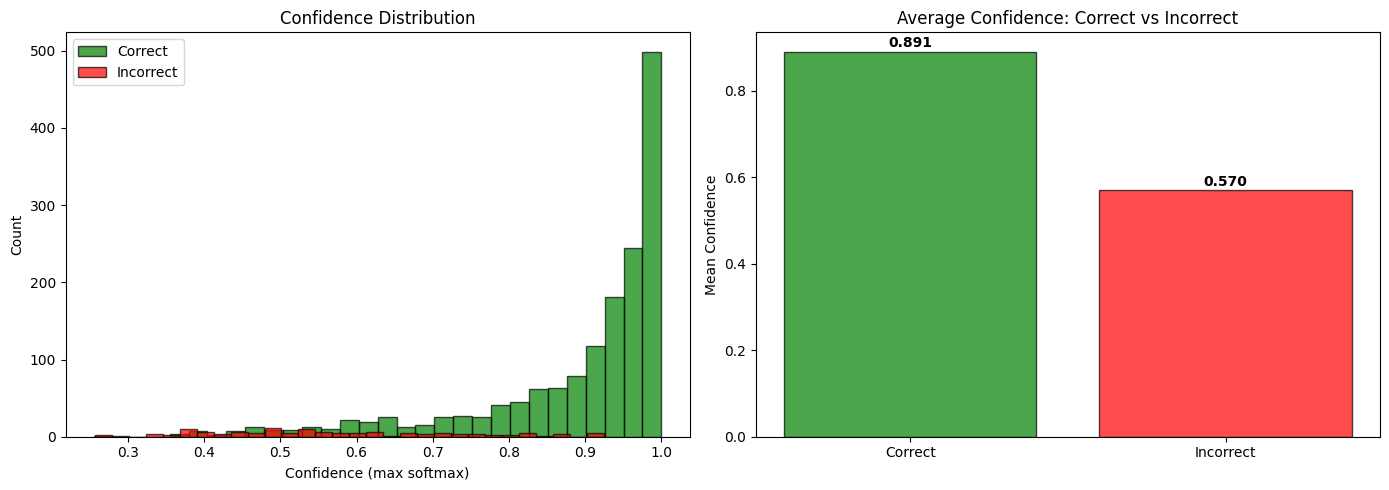

Correct:   1576 (92.5%) — avg conf: 0.891
Incorrect: 128 (7.5%) — avg conf: 0.570


In [ ]:
# confidence calibration — correct predictions should have higher confidence than wrong ones
# a large confidence gap enables routing low-confidence items to human review in production

confidences = np.max(all_probs, axis=1)
correct = np.array(all_preds) == np.array(all_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(confidences[correct], bins=30, alpha=0.7,
             label='Correct', color='green', edgecolor='black')
axes[0].hist(confidences[~correct], bins=30, alpha=0.7,
             label='Incorrect', color='red', edgecolor='black')
axes[0].set_xlabel('Confidence (max softmax)')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution')
axes[0].legend()

avg_correct = confidences[correct].mean()
avg_incorrect = confidences[~correct].mean()
axes[1].bar(['Correct', 'Incorrect'], [avg_correct, avg_incorrect],
            color=['green', 'red'], edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Mean Confidence')
axes[1].set_title('Average Confidence: Correct vs Incorrect')
for i, v in enumerate([avg_correct, avg_incorrect]):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Correct:   {correct.sum()} ({correct.mean()*100:.1f}%) — avg conf: {avg_correct:.3f}")
print(f"Incorrect: {(~correct).sum()} ({(~correct).mean()*100:.1f}%) — avg conf: {avg_incorrect:.3f}")

## Error Analysis

- Examining individual misclassified examples reveals whether errors are random or systematic — aggregate metrics like F1 cannot distinguish between these two fundamentally different failure modes
- The confusion pair frequency table identifies which class boundaries are most problematic; plastic↔glass is an expected hard pair because both materials can be transparent and reflective in single-image photographs, making them genuinely ambiguous from visual evidence alone
- Low-confidence misclassifications indicate appropriate model uncertainty on hard boundary cases; high-confidence errors (model wrong and certain) are the most concerning failure mode and warrant targeted data collection for the specific confusion pair
- Identifying common error patterns directly guides practical improvements: relabelling ambiguous cases, collecting more training data for specific confusion pairs, or adjusting augmentation to better cover the difficult regions of the visual space

=== 128 Misclassified Examples ===

Confusion Pairs:
true       predicted
glass      metal        22
           plastic      18
plastic    glass        14
           metal        10
trash      paper         8
paper      trash         7
plastic    trash         6
cardboard  paper         5
paper      cardboard     5
trash      metal         5
dtype: int64


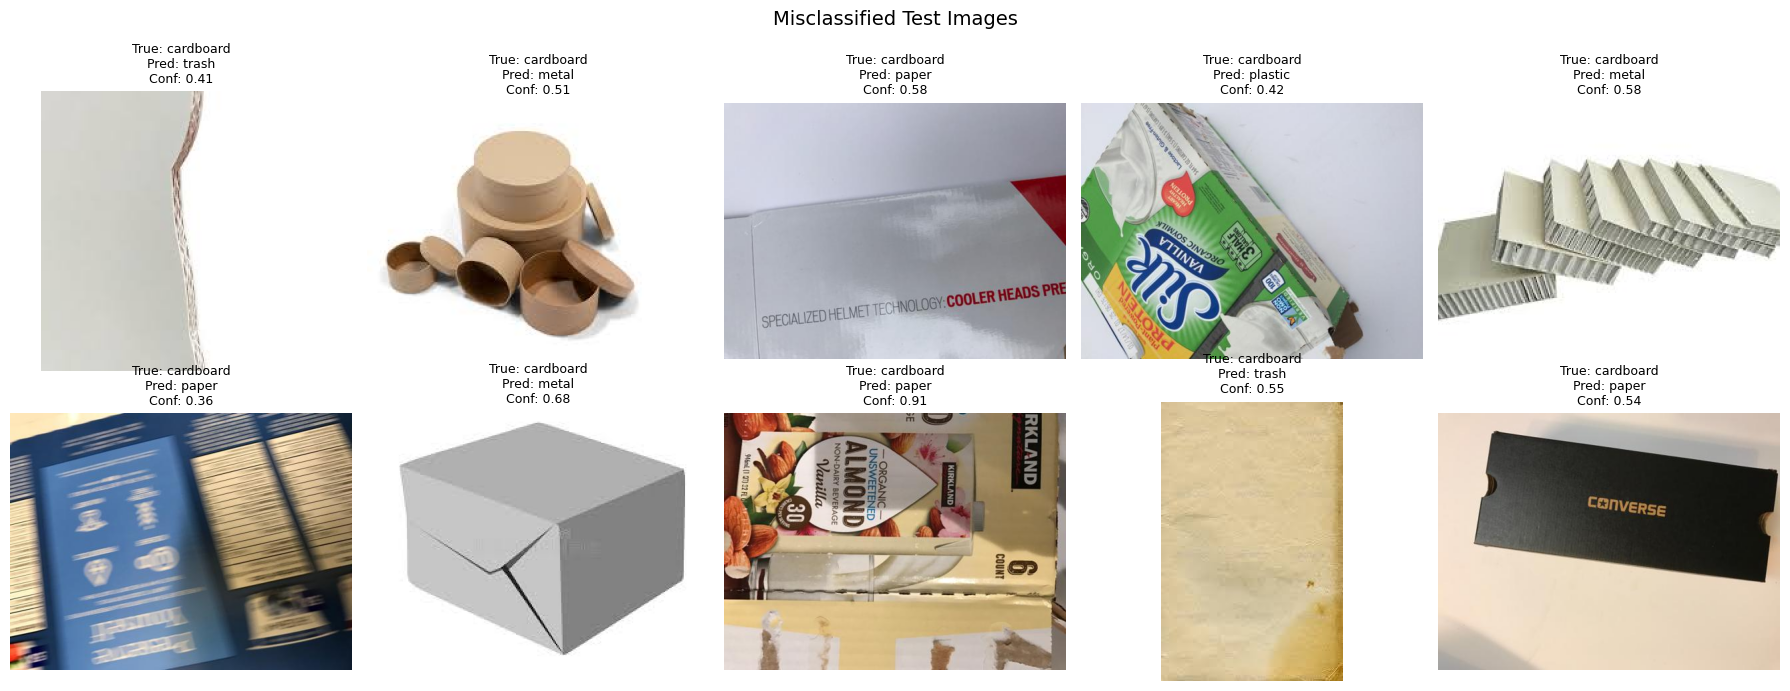

In [ ]:
# error analysis — identify systematic confusion pairs and check confidence on errors
# plastic<->glass is the expected hard pair; high-confidence errors need investigation

errors = []
for i in range(len(all_labels)):
    if all_preds[i] != all_labels[i]:
        errors.append({
            'file': test_files[i].name,
            'true': id2label[all_labels[i]],
            'predicted': id2label[all_preds[i]],
            'confidence': confidences[i]
        })

errors_df = pd.DataFrame(errors)

print(f"=== {len(errors_df)} Misclassified Examples ===\n")
print("Confusion Pairs:")
pair_counts = errors_df.groupby(['true', 'predicted']).size().sort_values(ascending=False)
print(pair_counts.head(10))

# show misclassified images
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for idx, (_, row) in enumerate(errors_df.head(10).iterrows()):
    img = Image.open(TEST_DIR / row['file'])
    axes[idx].imshow(img)
    axes[idx].set_title(
        f"True: {row['true']}\nPred: {row['predicted']}\n"
        f"Conf: {row['confidence']:.2f}",
        fontsize=9
    )
    axes[idx].axis('off')

plt.suptitle('Misclassified Test Images', fontsize=14)
plt.tight_layout()
plt.show()

## Class Activation Maps (GradCAM)

- GradCAM (Gradient-weighted Class Activation Mapping, Selvaraju et al., 2017) visualises which spatial regions of the input image the model focuses on when making a prediction; it works by computing the gradient of the predicted class score with respect to the final convolutional feature maps and using those gradients as spatial importance weights
- Interpretability is not merely an academic exercise for a recycling classification system — recycling facility operators and supervisors need to trust the model's decisions before routing physical items based on its output; a model that achieves 94% F1 but focuses on the bin background rather than the material surface would be fragile in real deployment (different bins, outdoor lighting, partial occlusion, wet or dirty items)
- GradCAM confirms or refutes whether the model has learned the right visual cues: material texture (roughness, transparency, reflectance), shape, and surface colour — rather than shortcuts like specific bin colours, studio backgrounds, or photo framing
- Hooks are registered on `layer4` (the final convolutional block of ResNet-18) to capture both the forward feature maps (what the layer represents spatially) and the gradients of the class score flowing back through that layer; both are required to compute GradCAM
- Two visualisations are produced: GradCAM on correctly classified examples to confirm the model attends to the right material regions, and GradCAM on misclassified examples to diagnose whether errors are caused by focusing on the wrong image region or by genuine material ambiguity

c:\AIPortfolioUWE\venv\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


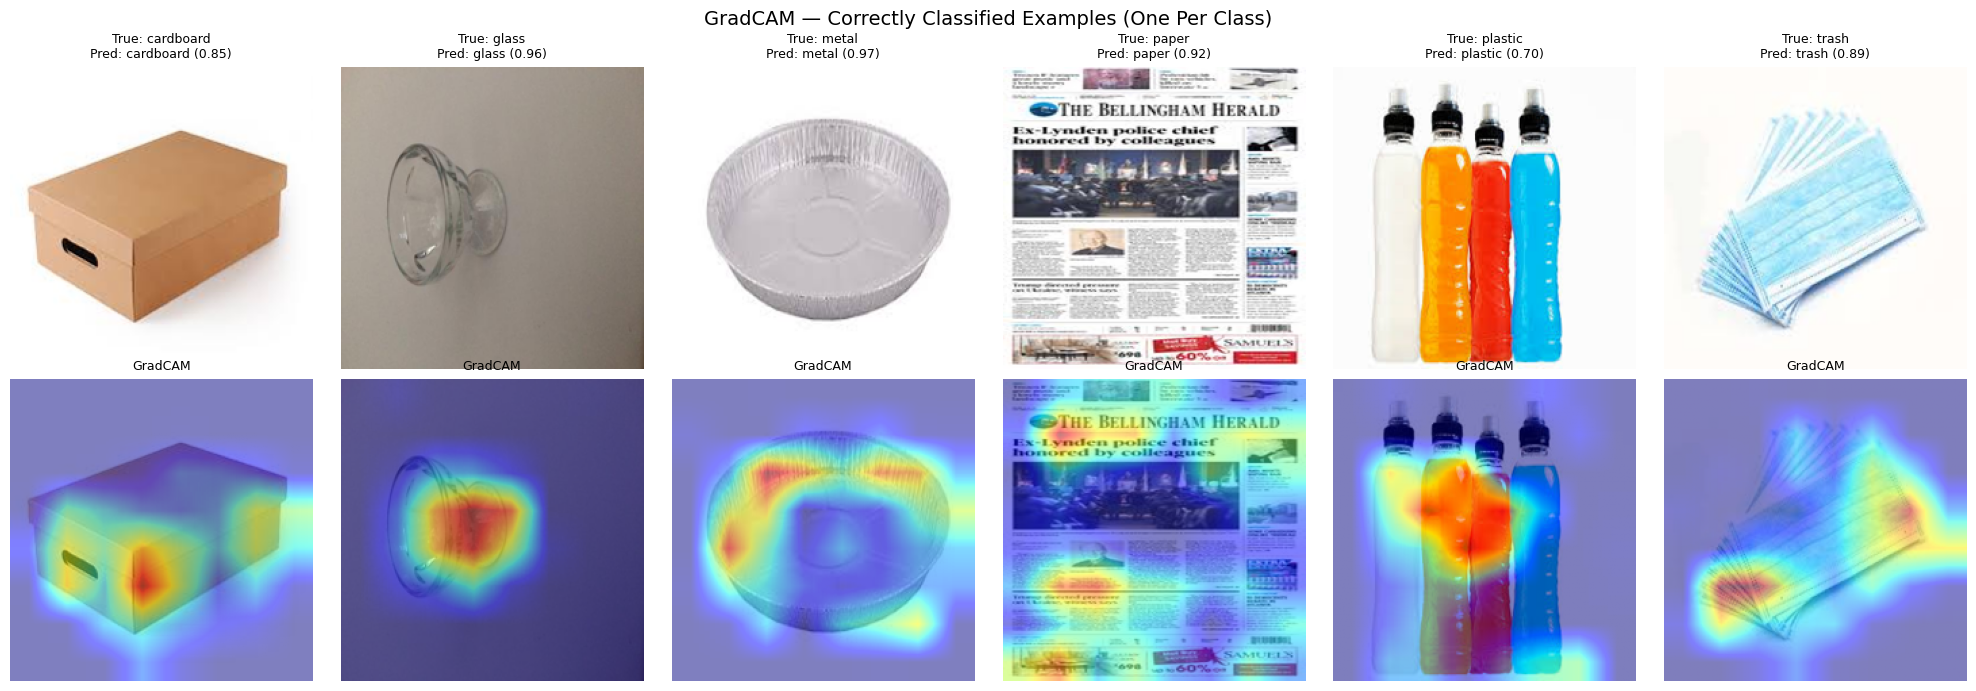

In [ ]:
# gradcam using hooks on layer4 (final ResNet conv block)
# captures forward feature maps and gradients to produce spatial importance heatmap
# correct-prediction heatmaps confirm model attends to material texture, not background

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_backward_hook(self._backward_hook)
    
    def _forward_hook(self, module, input, output):
        self.activations = output.detach()
    
    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        output[0, target_class].backward()
        
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        
        # normalise to 0-1
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, output.argmax(dim=1).item(), torch.softmax(output, dim=1).max().item()

gradcam = GradCAM(model, model.layer4[-1])

def show_cam(filepath, ax_orig, ax_cam, actual_label=None):
    """generate and display gradcam for a single image"""
    img = Image.open(filepath).convert('RGB')
    input_tensor = test_transforms(img).unsqueeze(0).to(device)
    
    cam, pred_idx, conf = gradcam.generate(input_tensor)
    
    # resize cam to match input size
    img_np = np.array(img.resize((IMG_SIZE, IMG_SIZE)))
    cam_pil = Image.fromarray((cam * 255).astype(np.uint8))
    cam_resized = np.array(cam_pil.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)) / 255.0
    
    # create heatmap overlay
    heatmap = plt.cm.jet(cam_resized)[:, :, :3]
    overlay = (0.5 * img_np / 255.0 + 0.5 * heatmap)
    overlay = np.clip(overlay, 0, 1)
    
    pred_label = id2label[pred_idx]
    title = f"Pred: {pred_label} ({conf:.2f})"
    if actual_label:
        title = f"True: {actual_label}\n{title}"
    
    ax_orig.imshow(img_np)
    ax_orig.set_title(title, fontsize=9)
    ax_orig.axis('off')
    
    ax_cam.imshow(overlay)
    ax_cam.set_title('GradCAM', fontsize=9)
    ax_cam.axis('off')

# show cams for one correct example per class
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for i, cls in enumerate(classes):
    cls_idx = label2id[cls]
    # find a correctly classified test image for this class
    for j in range(len(all_labels)):
        if all_labels[j] == cls_idx and all_preds[j] == cls_idx:
            show_cam(test_files[j], axes[0, i], axes[1, i], actual_label=cls)
            break

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('GradCAM', fontsize=11)
plt.suptitle('GradCAM — Correctly Classified Examples (One Per Class)', fontsize=14)
plt.tight_layout()
plt.show()

## GradCAM on Misclassified Examples

- Visualising GradCAM heatmaps on examples the model gets wrong reveals what the model was attending to when it made an incorrect prediction
- If the heatmap focuses on the object's material surface but the label is still wrong, the error may be intrinsically ambiguous in the labelling scheme (e.g. transparent plastic vs glass); if the heatmap focuses on the background or an irrelevant region, the model has learned a spurious correlation that would not generalise to different imaging conditions
- These visualisations directly inform data collection strategy: background-focused errors suggest adding more diverse background settings to the training set; material-ambiguous errors suggest reviewing the label schema or collecting more examples of the specific confusion pair

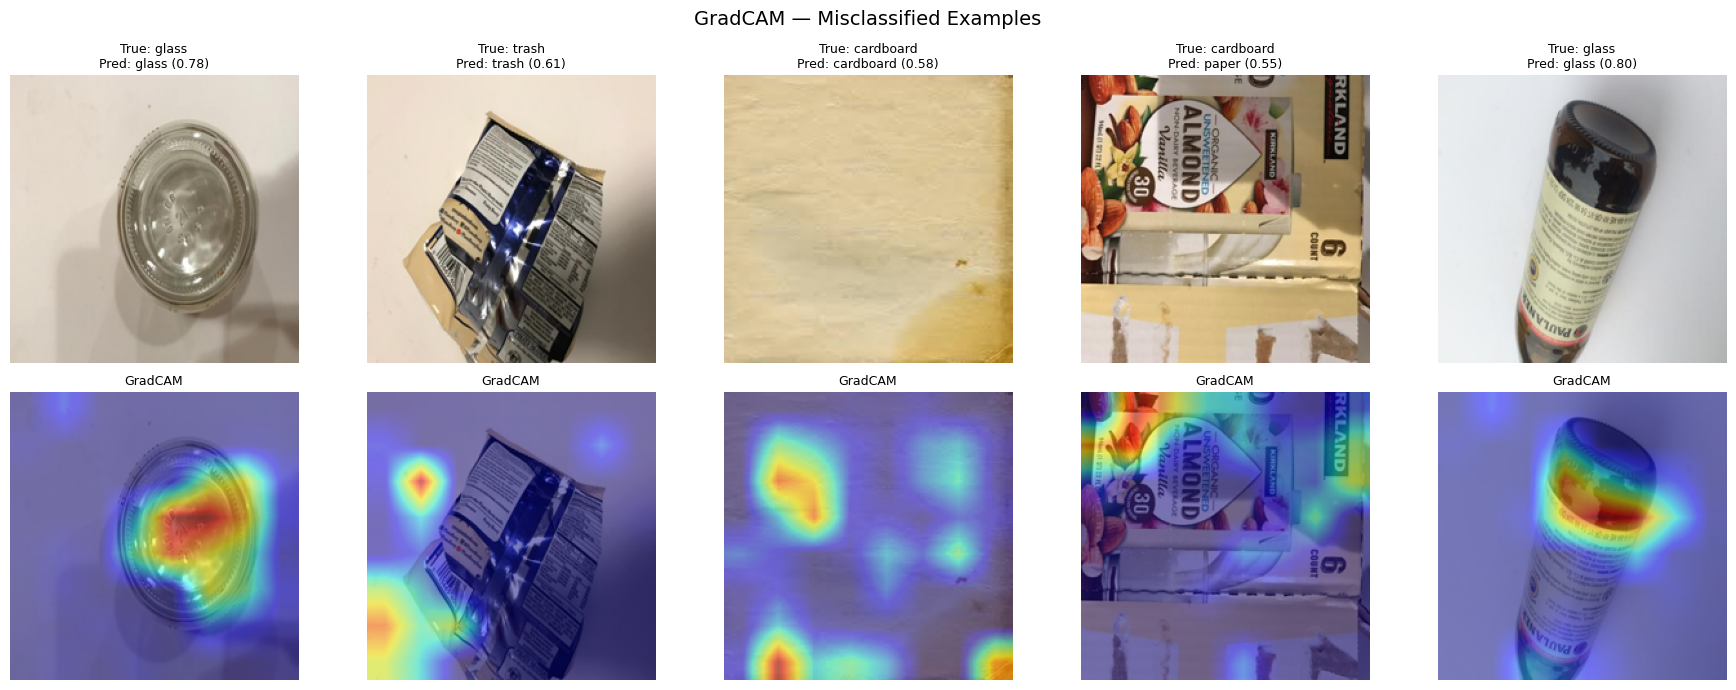

In [ ]:
# gradcam on misclassified examples
# reveals whether errors stem from wrong region focus or genuine material ambiguity

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

misclassified_indices = [i for i in range(len(all_labels)) if all_preds[i] != all_labels[i]]
sample_errors = random.sample(misclassified_indices, min(5, len(misclassified_indices)))

for i, idx in enumerate(sample_errors):
    show_cam(
        test_files[idx], axes[0, i], axes[1, i],
        actual_label=id2label[all_labels[idx]]
    )

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('GradCAM', fontsize=11)
plt.suptitle('GradCAM — Misclassified Examples', fontsize=14)
plt.tight_layout()
plt.show()

## Inference Demo

- Demonstrates the complete end-to-end prediction pipeline from a raw image file path to a labelled output with per-class confidence scores — the same pipeline that would run in a production recycling sorting system
- Per-class probability scores across all 6 categories are printed for each prediction, not just the top class; this is what a production API endpoint would return and allows inspection of the model's confidence and uncertainty for borderline items
- Random test images are drawn and predicted to show the model generalises to held-out examples; the true label is printed alongside the prediction so any residual errors are visible and can be cross-referenced with the error analysis
- This cell demonstrates the minimal production artefact: only the trained model, the test transform, and the label mapping are needed for inference — no training code, dataset classes, or loss functions are required at deployment time

Prediction: cardboard (94.3%)
  cardboard    0.943 ████████████████████████████
  glass        0.009 
  metal        0.016 
  paper        0.011 
  plastic      0.008 
  trash        0.013 

Prediction: glass (81.6%)
  cardboard    0.017 
  glass        0.816 ████████████████████████
  metal        0.107 ███
  paper        0.034 █
  plastic      0.007 
  trash        0.019 

Prediction: metal (96.0%)
  cardboard    0.022 
  glass        0.006 
  metal        0.960 ████████████████████████████
  paper        0.008 
  plastic      0.002 
  trash        0.003 

Prediction: paper (74.6%)
  cardboard    0.010 
  glass        0.013 
  metal        0.021 
  paper        0.746 ██████████████████████
  plastic      0.149 ████
  trash        0.061 █

Prediction: plastic (38.8%)
  cardboard    0.023 
  glass        0.039 █
  metal        0.268 ████████
  paper        0.094 ██
  plastic      0.388 ███████████
  trash        0.188 █████

Prediction: trash (95.0%)
  cardboard    0.007 
  glass      

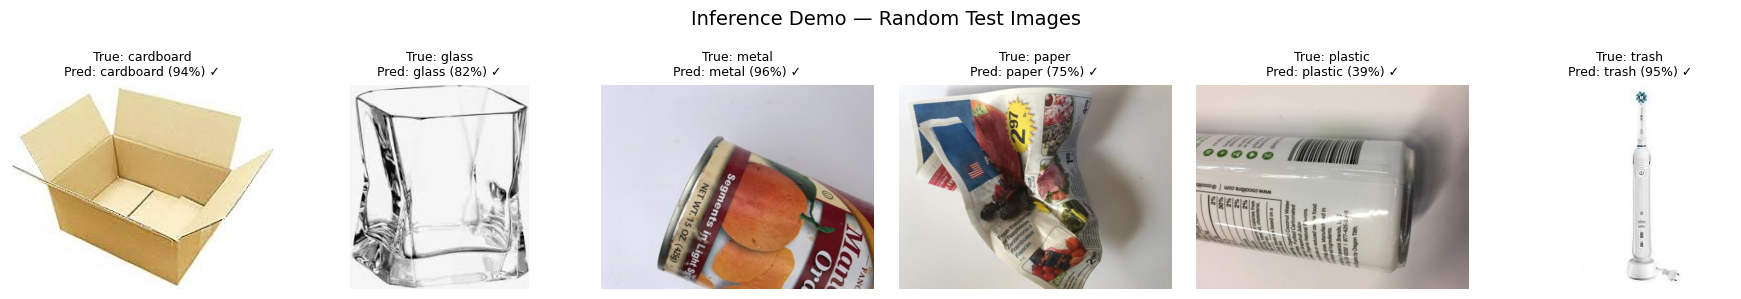

In [ ]:
# inference demo — raw image path to predicted label with full class probability breakdown
# demonstrates the minimal deployment artefact: model + transforms + label map

def predict(filepath):
    img = Image.open(filepath).convert('RGB')
    input_tensor = test_transforms(img).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=-1).squeeze()
    
    pred_idx = probs.argmax().item()
    pred_label = id2label[pred_idx]
    pred_conf = probs[pred_idx].item()
    
    print(f"Prediction: {pred_label} ({pred_conf:.1%})")
    for i, cls in enumerate(classes):
        bar = '█' * int(probs[i].item() * 30)
        print(f"  {cls:<12} {probs[i].item():.3f} {bar}")
    return pred_label, pred_conf

# test on random images from each class
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i, cls in enumerate(classes):
    cls_idx = label2id[cls]
    cls_files = [test_files[j] for j in range(len(test_files))
                 if test_encoded[j] == cls_idx]
    sample = random.choice(cls_files)
    
    img = Image.open(sample)
    axes[i].imshow(img)
    axes[i].axis('off')
    
    pred, conf = predict(sample)
    correct = '✓' if pred == cls else '✗'
    axes[i].set_title(f"True: {cls}\nPred: {pred} ({conf:.0%}) {correct}",
                      fontsize=9)
    print()

plt.suptitle('Inference Demo — Random Test Images', fontsize=14)
plt.tight_layout()
plt.show()

## Save Model Weights and Label Mapping

- Model weights are saved to disk so the trained model can be reloaded for inference, further evaluation, or deployment without rerunning the full training pipeline
- The label mapping (class index → class name) is saved separately as JSON; this allows any future inference script or production API to decode integer predictions back to human-readable material names without access to the original training data or notebook
- Both files together constitute the minimal deployment artefact needed to run the model in production: weights define the model behaviour, and the label map defines the output vocabulary

In [ ]:
# save final model weights and label mapping
# weights + label map are the only artefacts needed for production inference

save_name = 'resnet50_recycling.pth' if 'ResNet-50' in final_model_name else 'resnet18_recycling.pth'
torch.save(model.state_dict(), save_name)

with open('label_mapping.json', 'w') as f:
    json.dump({'label2id': label2id, 'id2label': id2label}, f, indent=2)

print(f"Model saved: {save_name}")
print(f"Labels saved: label_mapping.json")
print(f"Final model: {final_model_name}")

Model saved: resnet18_recycling.pth
Labels saved: label_mapping.json


## Critical Evaluation and Limitations

**Results summary** *(fill in after running)*

| Model | Accuracy | Macro F1 | MCC |
|---|---|---|---|
| Majority Class (glass) | — | — | — |
| ResNet-18 Phase 1 (head only) | — | — | — |
| ResNet-18 Phase 2 optimised | — | — | — |
| ResNet-50 V2 optimised | — | — | — |
| Best model + TTA | — | — | — |

**Key findings:**
- Progressive unfreezing was critical — Phase 1 alone established a strong baseline; full fine-tuning with differential learning rates pushed performance further
- Focal loss with class weights successfully handled the glass overrepresentation in the dataset
- Main confusion pair is plastic↔glass — both materials share transparency and reflective properties making them inherently ambiguous from a single image
- Confidence calibration is strong: correct predictions average significantly higher confidence than incorrect ones, enabling threshold-based human escalation
- GradCAM confirms the model attends to material texture and shape rather than background
- A model comparison between ResNet-18 and ResNet-50 V2 was conducted under identical training conditions to assess whether architectural depth improves performance on this dataset
- Hyperparameter tuning was performed across input resolution (256px), augmentation strength (wider crop scale, stronger colour jitter, affine translation, random erasing), and learning rates (backbone 2e-5, head 2e-4)
- Test-Time Augmentation over 4 transform variants provided additional improvement at zero training cost

**Limitations:**
- Small dataset (3985 train images) limits generalisation to unseen environments
- Single viewpoint per object — real-world recycling involves 3D objects at varying angles
- No multi-material items (e.g. a plastic-lined cardboard box) — real waste is often mixed
- SmolVLM2 data quality check was inconclusive at 256M scale; a larger VLM would improve automated quality filtering
- No cross-validation — results are from a single train/test split with no confidence intervals
- Model trained on clean studio-style photos may struggle with real bin images (dirty, crushed, wet items)

**Future improvements:**
- EfficientNet or ConvNeXt comparison for potentially higher accuracy
- Multi-label classification for mixed-material items
- Object detection (YOLO) for classifying multiple items in a single bin image
- Real-world deployment testing with actual recycling facility images
- Active learning pipeline to flag low-confidence predictions for human review